--- STEP 1: Loading & Bridging Datasets ---
Preprocessing complete. Training samples: 19

--- STEP 2: Training & Evaluating 5 Algorithms ---

All 5 Algorithms Performance:
                        RMSE  R2 Score
Linear Regression  10.091250  0.807087
Ridge Regression   11.682460  0.741452
Decision Tree      26.590736 -0.339469
Random Forest      26.389599 -0.319281
Gradient Boosting  26.461874 -0.326518

--- STEP 3: Best 2 Models Selected ---
-> Ridge Regression: R2 = 0.7415, RMSE = 11.6825
-> Gradient Boosting: R2 = -0.3265, RMSE = 26.4619


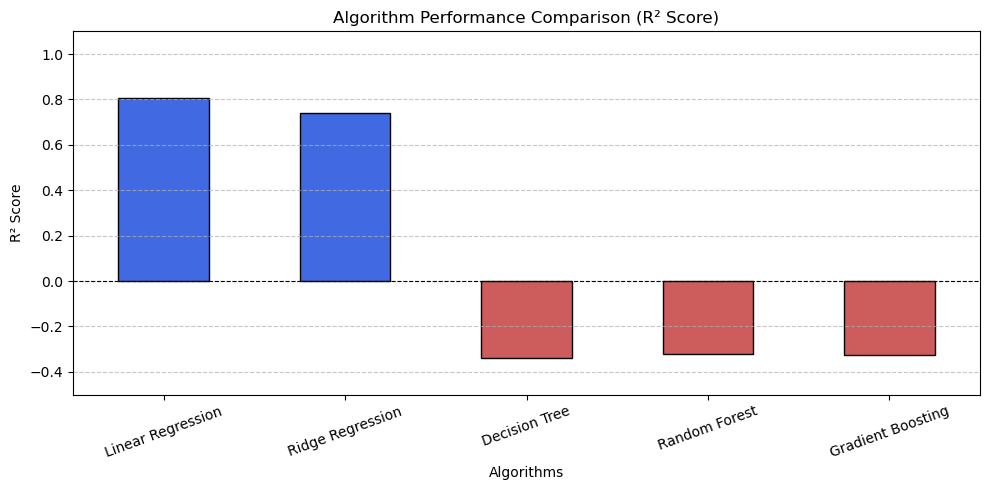

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# ==========================================
# STEP 1: DATA BRIDGING & PREPROCESSING
# ==========================================
print('--- STEP 1: Loading & Bridging Datasets ---')

# Load raw datasets from your workspace folder
df_ward = pd.read_csv('ward_level_collated.csv')
df_train = pd.read_csv('Mumbai Local Train Dataset.csv', encoding='latin1')

# Define station-to-ward mapping dictionary for Mumbai suburban lines
station_to_ward = {
    'Churchgate': 'A',
    'Marine Lines': 'A',
    'Charni Road': 'D',
    'Grant Road': 'D',
    'Mumbai Central': 'E',
    'Mahalakshmi': 'G/S',
    'Lower Parel': 'G/S',
    'Prabhadevi': 'G/S',
    'Dadar': 'G/N',
    'Matunga Road': 'G/N',
    'Mahim Jn': 'G/N',
    'Bandra': 'H/W',
    'Khar Road': 'H/W',
    'Santacruz': 'H/W',
    'Vile Parle': 'K/W',
    'Andheri': 'K/W',
    'Jogeshwari': 'K/W',
    'Ram Mandir': 'K/W',
    'Goregaon': 'P/N',
    'Malad': 'P/N',
    'Kandivli': 'R/S',
    'Borivali': 'R/S',
    'Dahisar': 'R/N',
    'Mira Road': 'R/N',
    'CSMT': 'A',
    'Masjid': 'B',
    'Sandhurst Road': 'B',
    'Byculla': 'E',
    'Chinchpokli': 'E',
    'Currey Road': 'G/S',
    'Parel': 'G/S',
    'Matunga': 'F/N',
    'Sion': 'F/N',
    'Kurla': 'L',
    'Vidhyavihar': 'N',
    'Ghatkopar': 'N',
    'Vikhroli': 'N',
    'Kanjurmarg': 'S',
    'Bhandup': 'S',
    'Nahur': 'S',
    'Mulund': 'T',
    'Reay Road': 'E',
    'Cotton Green': 'E',
    'Sewri': 'E',
    'Wadala Road': 'F/N',
    'GTB Nagar': 'F/N',
    'Chunabhatti': 'L',
    'Chembur': 'M/W',
    'Govandi': 'M/W',
    'Mankhurd': 'M/W',
}

# Map stations to wards and aggregate metrics
df_train['Ward_Alphabet'] = df_train['Station'].map(station_to_ward).fillna('K/E')
station_agg = (
    df_train.groupby('Ward_Alphabet')
    .agg(
        Station_Count=('Station', 'count'),
        Avg_Platforms=('Platforms', 'mean'),
        Total_Passengers=('Number of Passengers ', 'sum'),
    )
    .reset_index()
)

# Merge demographic ward data with transit station data
merged_df = pd.merge(df_ward, station_agg, on='Ward_Alphabet', how='left')
merged_df['Station_Count'] = merged_df['Station_Count'].fillna(1)
merged_df['Avg_Platforms'] = merged_df['Avg_Platforms'].fillna(2.0)

# Feature Engineering
merged_df['Commercial_Density'] = (
    merged_df['MAIN_OT_P'] / merged_df['Land_Area']
)
merged_df['Avg_Distance_to_Station'] = merged_df['Land_Area'] / (
    merged_df['Station_Count'] * 2.5
)
merged_df['Accessibility_Score'] = (
    merged_df['Station_Count'] * 15000.0
) / (merged_df['TOT_P_DEN'] + 100) + (
    merged_df['P_LIT'] / merged_df['TOT_P'] * 10
)

# Define Feature Matrix (X) and Target Variable (y)
X = merged_df[
    [
        'TOT_P',
        'TOT_M',
        'TOT_F',
        'Station_Count',
        'Avg_Distance_to_Station',
        'Commercial_Density',
    ]
]
y = merged_df['Accessibility_Score']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling (for Linear Models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Preprocessing complete. Training samples: {X_train.shape[0]}')

# ==========================================
# STEP 2: TRAINING & EVALUATING 5 ALGORITHMS
# ==========================================
print('\n--- STEP 2: Training & Evaluating 5 Algorithms ---')

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

results = {}

for name, model in models.items():
  if name in ['Linear Regression', 'Ridge Regression']:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
  else:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

  rmse = np.sqrt(mean_squared_error(y_test, preds))
  r2 = r2_score(y_test, preds)
  results[name] = {'RMSE': rmse, 'R2 Score': r2}

results_df = pd.DataFrame(results).T
print('\nAll 5 Algorithms Performance:')
print(results_df)

# ==========================================
# STEP 3: HIGHLIGHTING THE BEST 2 ALGORITHMS
# ==========================================
print('\n--- STEP 3: Best 2 Models Selected ---')
best_models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

for name, model in best_models.items():
  if name == 'Ridge Regression':
    model.fit(X_train_scaled, y_train)
    p = model.predict(X_test_scaled)
  else:
    model.fit(X_train, y_train)
    p = model.predict(X_test)

  print(
      f'-> {name}: R2 = {r2_score(y_test, p):.4f}, RMSE ='
      f' {np.sqrt(mean_squared_error(y_test, p)):.4f}'
  )

# ==========================================
# STEP 4: UPDATED VISUALIZATION PLOT
# ==========================================
plt.figure(figsize=(10, 5))

# Use colors to highlight positive vs negative models
colors = [
    'royalblue' if val >= 0 else 'indianred'
    for val in results_df['R2 Score']
]
results_df['R2 Score'].plot(kind='bar', color=colors, edgecolor='black')

plt.title('Algorithm Performance Comparison (R² Score)')
plt.ylabel('R² Score')
plt.xlabel('Algorithms')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # Zero line
plt.ylim(
    -0.5, 1.1
)  # Expanded lower limit so negative tree models are visible!
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()